# Real → synthetic fine-tuning benchmark

Fine-tune the pretrained CRATER Humvee component detector and part-damage
classifiers in two controlled stages: **reviewed real data first**, then the
**original + newly supplied synthetic data**. Model selection uses the fixed
real validation split; the real test split is opened once for the final paired
comparison.

This notebook is the experiment log and handoff artifact. Run cells in order.
Long GPU training is gated by one parameter in the next section.


## tl;dr

The notebook produces paired real-only vs. real→synthetic benchmarks for:

- YOLOX-S component detection: real validation/test AP50:95 and AP50;
- ResNet18 damage classification: accuracy, macro F1, calibration and
  per-class confusion on the same real test crops; and
- qualitative test-inference grids for both tasks.

**No conclusion is pre-filled.** After the GPU stages run, the last cell writes
the observed deltas and states whether synthetic adaptation earned promotion.


## Context & Methods

### Key assumptions

- The promoted civilian Carparts23 YOLOX-S checkpoint is the detector parent.
- Each real/synthetic damage model starts from ImageNet or its matching real
  checkpoint, respectively.
- Synthetic images are training-only. Validation and test remain real-only.
- Real image groups remain intact across the deterministic 70/15/15 split.
- Human CVAT boxes/attributes are authoritative; prompt-like filenames are
  provenance, not labels.
- The newly supplied batch is explicitly admitted because it was delivered as
  labeled data for this experiment. Its annotated grid is displayed before
  training. Change `ACCEPT_NEW_SYNTHETIC_CVAT` to `False` to require a separate
  row-by-row review decision.

Promotion is decided on real validation metrics. Test results describe the
frozen alternatives and must not be used for another tuning round.


## Setup


In [1]:
import csv
import hashlib
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import time
from collections import Counter, defaultdict
from dataclasses import asdict
from pathlib import Path

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import cv2
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "configs/taxonomy.json").is_file()),
    None,
)
assert ROOT is not None, "Run from the CRATER repository or a child directory."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
YOLOX_ROOT = ROOT / "third_party" / "YOLOX"
if str(YOLOX_ROOT) not in sys.path:
    # Keep the repository's own `tools` package ahead of YOLOX's package.
    sys.path.insert(1, str(YOLOX_ROOT))

from tools.data.import_cvat_damage_annotations import sha256_file
from tools.data.prepare_damage_classification import (
    REVIEW_FIELDS,
    apply_review,
    load_inventory,
    materialize_crops,
    proposed_review_rows,
    read_csv,
    write_csv,
)
from experiments.damage.training import (
    TrainingConfig,
    build_model,
    final_comparison,
    load_completed_stage,
    train_stage,
)

print(f"Repository: {ROOT}")
print(f"Python: {sys.version.split()[0]}; PyTorch: {torch.__version__}")
print("CUDA:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "not available")


c:\Users\jrwhite\AppData\Local\miniconda3\envs\crater\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: c:\Users\jrwhite\Documents\Projects\crater
Python: 3.10.20; PyTorch: 2.11.0+cu128
CUDA: NVIDIA RTX 5000 Ada Generation


## Parameters


In [2]:
RUN_NAME = "humvee_real_then_all_synthetic_20260917"
RUN_DIR = ROOT / "outputs" / "benchmarks" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Flip once the preflight tables and annotation grid look right.
RUN_LONG_TRAINING = True
ACCEPT_NEW_SYNTHETIC_CVAT = True
SEED = 42

SYNTHETIC_SOURCES = (
    "synthetic_humvee_damage_v1",
    "synthetic_humvee_additions_v2",
)
NEW_SYNTHETIC_SOURCE = "synthetic_humvee_additions_v2"

PROMOTED_CARPARTS_CHECKPOINT = (
    ROOT / "outputs/detection/civilian/promoted/carparts23-yolox-s-coco-v1/"
    "carparts23-yolox-s-coco-v1.pth"
)
PROMOTED_CARPARTS_SHA256 = "5ab8c99a5a67ca253aea6f1d4a6974f827b5e5bd16aca227306c129a7fd94d47"
DETECTOR_REAL_EPOCHS = 100
DETECTOR_SYNTHETIC_EPOCHS = 30
DETECTOR_BATCH_SIZE = 8
# Multiprocessing DataLoader workers are unreliable when YOLOX is launched
# from a Windows notebook. In-process loading is slower but deterministic.
DETECTOR_WORKERS = 0

DAMAGE_GROUPS = ("mobility", "structure", "mission_equipment")
DAMAGE_LEVELS = json.loads((ROOT / "configs/taxonomy.json").read_text())["damage"]["levels"]
DAMAGE_REAL_CONFIG = TrainingConfig(epochs=20, learning_rate=1e-4, batch_size=32, seed=SEED)
DAMAGE_SYNTHETIC_CONFIG = TrainingConfig(epochs=10, learning_rate=1e-5, batch_size=32, seed=SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

assert PROMOTED_CARPARTS_CHECKPOINT.is_file(), PROMOTED_CARPARTS_CHECKPOINT
assert sha256_file(PROMOTED_CARPARTS_CHECKPOINT) == PROMOTED_CARPARTS_SHA256
if RUN_LONG_TRAINING:
    assert torch.cuda.is_available(), "The detector benchmark requires the CUDA-enabled crater kernel."
print("Long training enabled:", RUN_LONG_TRAINING)


Long training enabled: True


## Data

### 1. Validate source inventories

This check verifies stored hashes, image dimensions, manual label provenance,
taxonomy membership and box geometry. It also makes the one box-free new image
explicit and excludes it instead of silently treating it as a detector negative.


In [3]:
damage_inventory = load_inventory(
    ROOT,
    include_synthetic=True,
    synthetic_source_names=SYNTHETIC_SOURCES,
)
damage_inventory_df = pd.DataFrame(damage_inventory)

source_profiles = []
synthetic_root = ROOT / "datasets/military/damage/source"
for source_name in SYNTHETIC_SOURCES:
    manifest = json.loads((synthetic_root / source_name / "import_manifest.json").read_text())
    source_profiles.append({
        "source_dataset": source_name,
        "images": manifest["image_count"],
        "boxes": manifest["box_count"],
        "empty_images": manifest["empty_image_count"],
        **{f"damage_{name}": manifest["canonical_damage_level_counts"].get(name, 0)
           for name in DAMAGE_LEVELS},
    })
real_manifest = json.loads(
    (synthetic_root / "humvee_cvat_damage_v1/import_manifest.json").read_text()
)
source_profiles.insert(0, {
    "source_dataset": "humvee_cvat_damage_v1",
    "images": real_manifest["image_count"],
    "boxes": real_manifest["box_count"],
    "empty_images": real_manifest["empty_image_count"],
    **{f"damage_{name}": real_manifest["canonical_damage_level_counts"].get(name, 0)
       for name in DAMAGE_LEVELS},
})
source_profile_df = pd.DataFrame(source_profiles)
display(source_profile_df)

duplicate_annotations = damage_inventory_df.annotation_id.duplicated().sum()
image_source_counts = (
    damage_inventory_df[["source_image_sha256", "source_dataset"]]
    .drop_duplicates()
    .groupby("source_image_sha256").source_dataset.nunique()
)
cross_source_duplicate_images = int((image_source_counts > 1).sum())
assert duplicate_annotations == 0
assert cross_source_duplicate_images == 0, "Identical image content appears in multiple source releases."
print(f"Validated {len(damage_inventory_df):,} damage boxes; cross-source duplicate images: 0")
display(pd.crosstab(
    [damage_inventory_df.source_dataset, damage_inventory_df.component_group],
    damage_inventory_df.damage_level,
).reindex(columns=DAMAGE_LEVELS, fill_value=0))


,source_dataset,images,boxes,empty_images,damage_no_visible_damage,damage_possible_damage,damage_severe_visible_damage,damage_unobservable
0,humvee_cvat_damage_v1,224,2240,2,2135,32,42,31
1,synthetic_humvee_damage_v1,30,251,0,188,22,31,10
2,synthetic_humvee_additions_v2,36,244,1,187,27,22,8


Validated 2,735 damage boxes; cross-source duplicate images: 0


damage_level                                     no_visible_damage  \
source_dataset                component_group                        
humvee_cvat_damage_v1         mission_equipment                460   
                              mobility                         753   
                              structure                        922   
synthetic_humvee_additions_v2 mission_equipment                 32   
                              mobility                          60   
                              structure                         95   
synthetic_humvee_damage_v1    mission_equipment                 35   
                              mobility                          59   
                              structure                         94   

damage_level                                     possible_damage  \
source_dataset                component_group                      
humvee_cvat_damage_v1         mission_equipment                2   
                              mobility                         4   
                              structure                       26   
synthetic_humvee_additions_v2 mission_equipment                1   
                              mobility                         7   
                              structure                       19   
synthetic_humvee_damage_v1    mission_equipment                2   
                              mobility                         9   
                              structure                       11   

damage_level                                     severe_visible_damage  \
source_dataset                component_group                            
humvee_cvat_damage_v1         mission_equipment                      1   
                              mobility                              22   
                              structure                             19   
synthetic_humvee_additions_v2 mission_equipment                      7   
                              mobility                               3   
                              structure                             12   
synthetic_humvee_damage_v1    mission_equipment                      5   
                              mobility                              10   
                              structure                             16   

damage_level                                     unobservable  
source_dataset                component_group                  
humvee_cvat_damage_v1         mission_equipment             0  
                              mobility                     29  
                              structure                     2  
synthetic_humvee_additions_v2 mission_equipment             0  
                              mobility                      8  
                              structure                     0  
synthetic_humvee_damage_v1    mission_equipment             0  
                              mobility                     10  
                              structure                     0

### 2. Inspect the newly supplied annotations


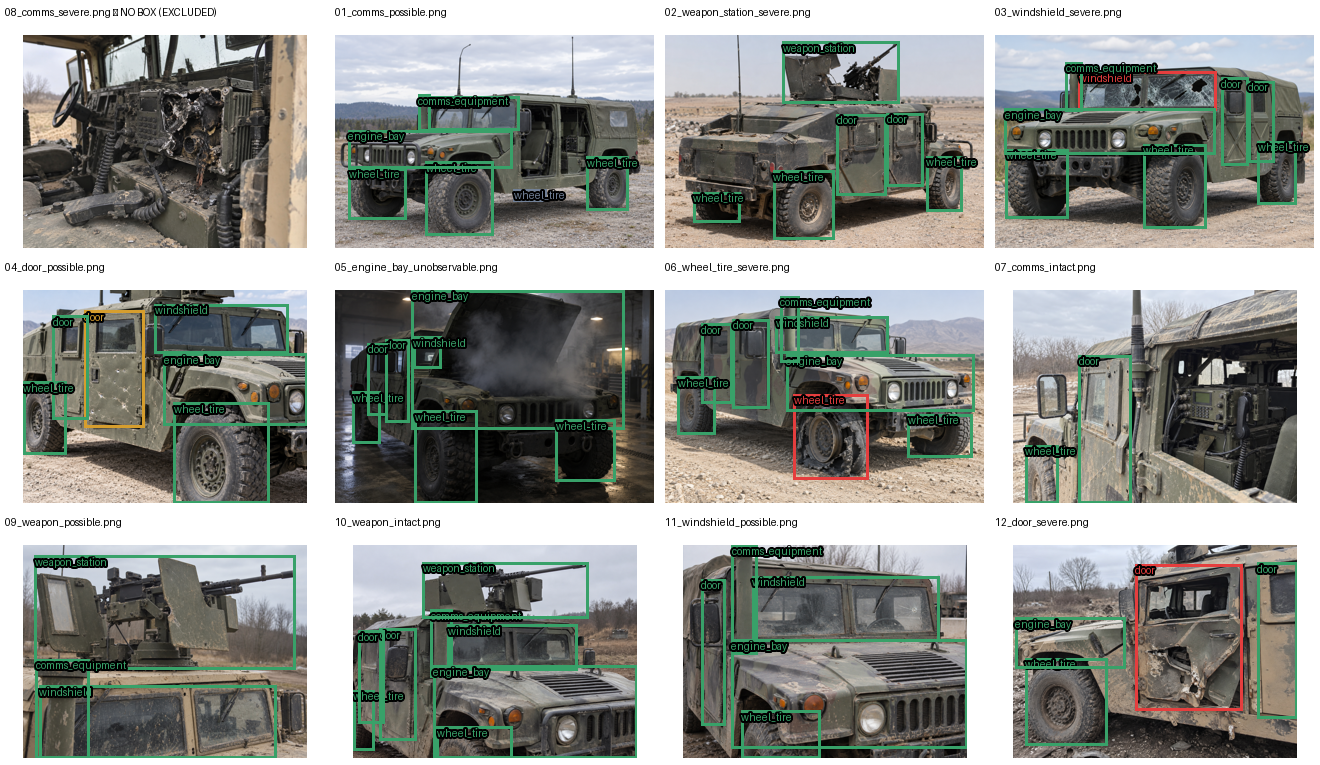

In [4]:
def draw_labeled_grid(source_name, max_images=12, columns=4, tile=(330, 255)):
    source_dir = synthetic_root / source_name
    labels = pd.DataFrame(read_csv(source_dir / "damage_box_annotations.csv"))
    manifest = pd.DataFrame(read_csv(source_dir / "source_manifest.csv"))
    boxes_by_name = {name: frame for name, frame in labels.groupby("source_image")}
    names = sorted(manifest.file_name)
    empty = [name for name in names if name not in boxes_by_name]
    selected = (empty + [name for name in names if name not in empty])[:max_images]
    rows = math.ceil(len(selected) / columns)
    grid = Image.new("RGB", (columns * tile[0], rows * tile[1]), "white")
    grid_draw = ImageDraw.Draw(grid)
    colors = {"no_visible_damage": "#38a169", "possible_damage": "#d69e2e",
              "severe_visible_damage": "#e53e3e", "unobservable": "#718096"}
    for index, name in enumerate(selected):
        with Image.open(source_dir / "images" / name) as raw:
            image = raw.convert("RGB")
        original_size = image.size
        image.thumbnail((tile[0] - 10, tile[1] - 42))
        sx, sy = image.width / original_size[0], image.height / original_size[1]
        draw = ImageDraw.Draw(image)
        for _, box in boxes_by_name.get(name, pd.DataFrame()).iterrows():
            coords = tuple(float(box[key]) for key in ("box_x1", "box_y1", "box_x2", "box_y2"))
            coords = (coords[0] * sx, coords[1] * sy, coords[2] * sx, coords[3] * sy)
            color = colors[box.damage_level]
            draw.rectangle(coords, outline=color, width=3)
            draw.text((coords[0], coords[1]), box.component_class, fill=color,
                      stroke_width=2, stroke_fill="black")
        col, row = index % columns, index // columns
        left = col * tile[0] + (tile[0] - image.width) // 2
        top = row * tile[1] + 35
        grid.paste(image, (left, top))
        suffix = " — NO BOX (EXCLUDED)" if name in empty else ""
        grid_draw.text((col * tile[0] + 5, row * tile[1] + 6), name + suffix, fill="black")
    display(grid)

draw_labeled_grid(NEW_SYNTHETIC_SOURCE)


### 3. Freeze the real split and materialize damage crops

Existing v1 review decisions are preserved. The new CVAT batch is accepted only
when `ACCEPT_NEW_SYNTHETIC_CVAT=True`; otherwise those rows stay pending and block
preparation. Synthetic crops always receive `train`.


In [5]:
REVIEW_PATH = RUN_DIR / "data/damage_review.csv"
CROP_DIR = RUN_DIR / "damage_data"
PREPARATION_PATH = RUN_DIR / "data/damage_preparation.json"
REVIEW_PATH.parent.mkdir(parents=True, exist_ok=True)

if not REVIEW_PATH.exists():
    previous_review_path = ROOT / "datasets/military/damage/review/humvee_real_synthetic_v1.csv"
    previous = {
        (row["domain"], row["source_image"]): row
        for row in read_csv(previous_review_path)
    }
    source_by_key = {
        (row["domain"], row["source_image"]): row["source_dataset"]
        for row in damage_inventory
    }
    review_rows = proposed_review_rows(damage_inventory)
    for row in review_rows:
        key = (row["domain"], row["source_image"])
        if key in previous:
            if previous[key]["source_image_sha256"] != row["source_image_sha256"]:
                raise ValueError(f"Prior review hash changed: {key}")
            row.update({field: previous[key][field] for field in ("group_id", "review_status")})
        elif (source_by_key[key] == NEW_SYNTHETIC_SOURCE
              and ACCEPT_NEW_SYNTHETIC_CVAT):
            row["review_status"] = "accept"
    write_csv(REVIEW_PATH, review_rows, REVIEW_FIELDS)

review_df = pd.DataFrame(read_csv(REVIEW_PATH))
display(pd.crosstab(review_df.domain, review_df.review_status))
if (review_df.review_status == "pending").any():
    raise ValueError(f"Resolve pending decisions in {REVIEW_PATH}")

reviewed_rows = apply_review(damage_inventory, REVIEW_PATH, seed=SEED)
preparation = {
    "review_sha256": sha256_file(REVIEW_PATH),
    "seed": SEED,
    "synthetic_sources": list(SYNTHETIC_SOURCES),
    "taxonomy_sha256": sha256_file(ROOT / "configs/taxonomy.json"),
}
if CROP_DIR.exists():
    assert PREPARATION_PATH.is_file(), "Existing crops have no preparation record."
    assert json.loads(PREPARATION_PATH.read_text()) == preparation, "Crop inputs changed; use a new RUN_NAME."
    crop_rows = read_csv(CROP_DIR / "crops_manifest.csv")
else:
    crop_rows = materialize_crops(ROOT, reviewed_rows, CROP_DIR)
    PREPARATION_PATH.write_text(json.dumps(preparation, indent=2) + "\n")
crop_df = pd.DataFrame(crop_rows)
display(pd.crosstab(
    [crop_df.domain, crop_df.split, crop_df.component_group],
    crop_df.damage_level,
).reindex(columns=DAMAGE_LEVELS, fill_value=0))


review_status,accept
domain,
real,222
synthetic,65


damage_level                       no_visible_damage  possible_damage  \
domain    split component_group                                         
real      test  mission_equipment                 55                1   
                mobility                         113                0   
                structure                        125                6   
          train mission_equipment                312                1   
                mobility                         527                4   
                structure                        651               18   
          val   mission_equipment                 93                0   
                mobility                         113                0   
                structure                        146                2   
synthetic train mission_equipment                 67                3   
                mobility                         119               16   
                structure                        189               30   

damage_level                       severe_visible_damage  unobservable  
domain    split component_group                                         
real      test  mission_equipment                      0             0  
                mobility                               4             1  
                structure                              1             0  
          train mission_equipment                      1             0  
                mobility                              16            23  
                structure                             18             1  
          val   mission_equipment                      0             0  
                mobility                               2             5  
                structure                              0             1  
synthetic train mission_equipment                     12             0  
                mobility                              13            18  
                structure                             28             0

### 4. Build detector datasets

Real COCO splits are copied without reassignment. Both synthetic releases are
converted from their validated CVAT box tables into one training-only COCO file.
Image files are hard-linked where supported (copied otherwise). The empty new
image is excluded because its filename implies an unannotated positive scene.


In [6]:
DETECTOR_DATA_DIR = RUN_DIR / "detector_data"
REAL_ANNOTATION_DIR = ROOT / "datasets/military/components/annotations"
REAL_COMPONENT_ROOT = ROOT / "datasets/military/components"

def link_or_copy(source, destination):
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        return
    try:
        os.link(source, destination)
    except OSError:
        shutil.copy2(source, destination)

def prepare_detector_data():
    input_paths = [
        REAL_ANNOTATION_DIR / f"humvee_source6_instances_{split}.json"
        for split in ("train", "val", "test")
    ]
    for source_name in SYNTHETIC_SOURCES:
        input_paths += [
            synthetic_root / source_name / "damage_box_annotations.csv",
            synthetic_root / source_name / "source_manifest.csv",
        ]
    input_hashes = {str(path.relative_to(ROOT)): sha256_file(path) for path in input_paths}
    signature = hashlib.sha256(
        json.dumps(input_hashes, sort_keys=True).encode("utf-8")
    ).hexdigest()
    manifest_path = DETECTOR_DATA_DIR / "dataset_manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        assert manifest["signature"] == signature, "Detector inputs changed; use a new RUN_NAME."
        return manifest
    if DETECTOR_DATA_DIR.exists() and any(DETECTOR_DATA_DIR.iterdir()):
        raise ValueError("Incomplete detector data directory; inspect it and use a new RUN_NAME.")
    (DETECTOR_DATA_DIR / "annotations").mkdir(parents=True, exist_ok=True)

    real_payloads = {}
    for split in ("train", "val", "test"):
        payload = json.loads(
            (REAL_ANNOTATION_DIR / f"humvee_source6_instances_{split}.json").read_text()
        )
        for image in payload["images"]:
            source = REAL_COMPONENT_ROOT / image["file_name"]
            relative = Path("images") / "real" / Path(image["file_name"]).name
            link_or_copy(source, DETECTOR_DATA_DIR / relative)
            image["file_name"] = relative.as_posix()
        output_name = f"real_{split}.json"
        (DETECTOR_DATA_DIR / "annotations" / output_name).write_text(
            json.dumps(payload, indent=2) + "\n"
        )
        real_payloads[split] = payload

    categories = real_payloads["train"]["categories"]
    category_by_name = {item["name"]: int(item["id"]) for item in categories}
    synthetic_images, synthetic_annotations = [], []
    next_image_id = next_annotation_id = 1
    synthetic_hashes = set()
    for source_name in SYNTHETIC_SOURCES:
        source_dir = synthetic_root / source_name
        labels = read_csv(source_dir / "damage_box_annotations.csv")
        labels_by_name = defaultdict(list)
        for row in labels:
            labels_by_name[row["source_image"]].append(row)
        for image_row in read_csv(source_dir / "source_manifest.csv"):
            name = image_row["file_name"]
            if not labels_by_name[name]:
                continue
            image_hash = image_row["sha256"]
            assert image_hash not in synthetic_hashes, f"Duplicate synthetic image: {name}"
            synthetic_hashes.add(image_hash)
            source = source_dir / "images" / name
            assert sha256_file(source) == image_hash
            relative = Path("images") / source_name / name
            link_or_copy(source, DETECTOR_DATA_DIR / relative)
            synthetic_images.append({
                "id": next_image_id,
                "file_name": relative.as_posix(),
                "width": int(image_row["width"]),
                "height": int(image_row["height"]),
                "source_dataset": source_name,
            })
            for row in labels_by_name[name]:
                x1, y1, x2, y2 = [float(row[f"box_{axis}"]) for axis in ("x1", "y1", "x2", "y2")]
                width, height = x2 - x1, y2 - y1
                synthetic_annotations.append({
                    "id": next_annotation_id,
                    "image_id": next_image_id,
                    "category_id": category_by_name[row["component_class"]],
                    "bbox": [x1, y1, width, height],
                    "area": width * height,
                    "iscrowd": 0,
                    "segmentation": [],
                })
                next_annotation_id += 1
            next_image_id += 1
    synthetic_payload = {
        "info": {"description": "CRATER synthetic Humvee components; training only"},
        "licenses": [],
        "categories": categories,
        "images": synthetic_images,
        "annotations": synthetic_annotations,
    }
    (DETECTOR_DATA_DIR / "annotations/synthetic_train.json").write_text(
        json.dumps(synthetic_payload, indent=2) + "\n"
    )
    manifest = {
        "signature": signature,
        "input_hashes": input_hashes,
        "real_counts": {
            split: {"images": len(payload["images"]), "boxes": len(payload["annotations"])}
            for split, payload in real_payloads.items()
        },
        "synthetic_counts": {
            "images": len(synthetic_images), "boxes": len(synthetic_annotations),
            "excluded_empty_images": sum(profile["empty_images"] for profile in source_profiles[1:]),
        },
        "policy": "synthetic_train_only; exclude_unannotated; fixed_real_validation_and_test",
    }
    manifest_path.write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest

detector_data_manifest = prepare_detector_data()
display(pd.DataFrame({
    **{f"real_{split}": values for split, values in detector_data_manifest["real_counts"].items()},
    "synthetic_train": detector_data_manifest["synthetic_counts"],
}).T.fillna(0).astype(int))


,images,boxes,excluded_empty_images
real_train,156,1598,0
real_val,34,322,0
real_test,34,306,0
synthetic_train,65,495,1


### 5. Check detector class coverage and split leakage


In [7]:
def coco_class_counts(path):
    payload = json.loads(path.read_text())
    names = {int(item["id"]): item["name"] for item in payload["categories"]}
    counts = Counter(names[int(row["category_id"])] for row in payload["annotations"])
    return {name: counts.get(name, 0) for name in names.values()}

coverage = {
    name: coco_class_counts(DETECTOR_DATA_DIR / "annotations" / file_name)
    for name, file_name in {
        "real_train": "real_train.json", "real_val": "real_val.json",
        "real_test": "real_test.json", "synthetic_train": "synthetic_train.json",
    }.items()
}
coverage_df = pd.DataFrame(coverage).T
display(coverage_df)
assert (coverage_df.loc[["real_train", "real_val", "real_test"]] > 0).all().all()

split_hashes = {}
for split in ("train", "val", "test"):
    payload = json.loads((DETECTOR_DATA_DIR / f"annotations/real_{split}.json").read_text())
    split_hashes[split] = {
        sha256_file(DETECTOR_DATA_DIR / image["file_name"]) for image in payload["images"]
    }
assert not (split_hashes["train"] & split_hashes["val"]
            or split_hashes["train"] & split_hashes["test"]
            or split_hashes["val"] & split_hashes["test"])
print("Real detector image hashes crossing splits: 0")


,wheel_tire,windshield,door,engine_bay,weapon_station,comms_equipment
real_train,599,206,309,190,178,116
real_val,96,39,49,40,36,62
real_test,107,37,55,39,41,27
synthetic_train,166,62,121,64,49,33


Real detector image hashes crossing splits: 0


## Results

### 6. Fine-tune the component detector

Stage 1 loads the promoted Carparts23 detector and trains on real Humvee boxes.
Stage 2 loads Stage 1's best checkpoint, uses a lower learning rate, and trains
on both synthetic releases. Both stages select epochs on the same real
validation COCO AP50:95.


In [8]:
TRAIN_SCRIPT = YOLOX_ROOT / "tools/train.py"
EXP_FILE = ROOT / "experiments/detection/yolox_s_crater6.py"
DETECTOR_OUTPUT_DIR = RUN_DIR / "detector"
# This Windows environment contains Intel OpenMP from both MKL-backed NumPy
# and the pip CUDA PyTorch wheel. Keep the workaround isolated to the YOLOX
# subprocess; OMP_NUM_THREADS=1 also avoids oversubscribing the notebook host.
TRAINING_ENV = {
    **os.environ,
    "TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD": "1",
    "KMP_DUPLICATE_LIB_OK": "TRUE",
    "OMP_NUM_THREADS": "1",
}
ANSI_ESCAPE = re.compile(r"\x1b\[[0-9;]*m")
PROGRESS_PATTERN = re.compile(r"epoch: (\d+)/(\d+), iter: (\d+)/(\d+)")

def detector_stage_signature(train_ann, parent, epochs, lr_per_image):
    payload = {
        "data_signature": detector_data_manifest["signature"],
        "train_ann": train_ann,
        "val_ann": "real_val.json",
        "test_ann": "real_test.json",
        "parent_sha256": sha256_file(parent),
        "epochs": epochs,
        "batch_size": DETECTOR_BATCH_SIZE,
        "workers": DETECTOR_WORKERS,
        "seed": SEED,
        "basic_lr_per_img": lr_per_image,
    }
    return payload, hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()

def train_detector_stage(stage_name, train_ann, parent, epochs, lr_per_image):
    stage_dir = DETECTOR_OUTPUT_DIR / stage_name
    checkpoint = stage_dir / "best_ckpt.pth"
    config_path = stage_dir / "benchmark_config.json"
    config, signature = detector_stage_signature(train_ann, parent, epochs, lr_per_image)
    if checkpoint.is_file():
        assert config_path.is_file(), f"Existing stage is missing {config_path.name}"
        assert json.loads(config_path.read_text())["signature"] == signature, (
            "Existing detector stage has different inputs; use a new RUN_NAME."
        )
        print(f"Reusing validated detector stage: {checkpoint}")
        return checkpoint
    if stage_dir.exists():
        archived = stage_dir.with_name(
            f"{stage_dir.name}_failed_{time.strftime('%Y%m%d_%H%M%S')}"
        )
        stage_dir.rename(archived)
        print(f"Archived incomplete detector stage to {archived}")

    command = [
        sys.executable, "-u", str(TRAIN_SCRIPT), "-f", str(EXP_FILE),
        "-d", "1", "-b", str(DETECTOR_BATCH_SIZE), "--fp16",
        "-l", "tensorboard", "-expn", stage_name, "-c", str(parent),
        "data_dir", str(DETECTOR_DATA_DIR),
        "train_ann", train_ann, "val_ann", "real_val.json", "test_ann", "real_test.json",
        "output_dir", str(DETECTOR_OUTPUT_DIR), "max_epoch", str(epochs),
        "warmup_epochs", "2", "no_aug_epochs", str(min(10, max(1, epochs // 5))),
        "eval_interval", "1", "data_num_workers", str(DETECTOR_WORKERS),
        "basic_lr_per_img", str(lr_per_image), "seed", str(SEED),
    ]
    progress = tqdm(total=epochs, desc=stage_name, unit="epoch")
    recent = []
    process = subprocess.Popen(
        command, cwd=ROOT, env=TRAINING_ENV, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    for raw_line in process.stdout:
        line = ANSI_ESCAPE.sub("", raw_line).strip()
        recent = (recent + [line])[-30:]
        match = PROGRESS_PATTERN.search(line)
        if match:
            epoch, maximum, iteration, total = map(int, match.groups())
            position = epoch - 1 + iteration / total
            progress.update(max(0, position - progress.n))
            progress.set_postfix(epoch=f"{epoch}/{maximum}", refresh=False)
    return_code = process.wait()
    progress.close()
    if return_code:
        print("\n".join(recent))
        raise subprocess.CalledProcessError(return_code, command)
    if not checkpoint.is_file():
        log_path = stage_dir / "train_log.txt"
        raise RuntimeError(
            "YOLOX exited without producing best_ckpt.pth. Its launcher can "
            "return exit code 0 after a logged exception. Inspect "
            f"{log_path}. Recent subprocess output:\n" + "\n".join(recent)
        )
    config_path.write_text(json.dumps({**config, "signature": signature}, indent=2) + "\n")
    return checkpoint


In [9]:
detector_checkpoints = {}
if RUN_LONG_TRAINING:
    detector_checkpoints["real"] = train_detector_stage(
        "real_only", "real_train.json", PROMOTED_CARPARTS_CHECKPOINT,
        DETECTOR_REAL_EPOCHS, 0.01 / 64,
    )
    detector_checkpoints["synthetic"] = train_detector_stage(
        "real_then_synthetic", "synthetic_train.json", detector_checkpoints["real"],
        DETECTOR_SYNTHETIC_EPOCHS, 0.002 / 64,
    )
else:
    print("Preflight complete. Set RUN_LONG_TRAINING=True and Run All for both detector stages.")


Reusing validated detector stage: c:\Users\jrwhite\Documents\Projects\crater\outputs\benchmarks\humvee_real_then_all_synthetic_20260917\detector\real_only\best_ckpt.pth
Reusing validated detector stage: c:\Users\jrwhite\Documents\Projects\crater\outputs\benchmarks\humvee_real_then_all_synthetic_20260917\detector\real_then_synthetic\best_ckpt.pth


### 7. Benchmark detector stages on fixed real validation and test sets


In [10]:
def evaluate_detector(checkpoint_path, split):
    from yolox.exp import get_exp

    assert split in {"val", "test"}
    exp = get_exp(str(EXP_FILE), None)
    exp.merge([
        "data_dir", str(DETECTOR_DATA_DIR), "train_ann", "real_train.json",
        "val_ann", "real_val.json", "test_ann", "real_test.json",
        "output_dir", str(DETECTOR_OUTPUT_DIR), "data_num_workers", str(DETECTOR_WORKERS),
    ])
    model = exp.get_model()
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    model.load_state_dict(checkpoint["model"])
    model.cuda().eval()
    evaluator = exp.get_evaluator(
        DETECTOR_BATCH_SIZE, False, testdev=(split == "test"), legacy=False
    )
    evaluator.per_class_AP = True
    evaluator.per_class_AR = True
    ap50_95, ap50, info = evaluator.evaluate(
        model, distributed=False, half=True, trt_file=None,
        decoder=None, test_size=exp.test_size,
    )
    return {"ap50_95": float(ap50_95), "ap50": float(ap50), "details": info}

detector_metrics = {}
if RUN_LONG_TRAINING:
    for stage, checkpoint in detector_checkpoints.items():
        detector_metrics[stage] = {
            split: evaluate_detector(checkpoint, split) for split in ("val", "test")
        }
    (DETECTOR_OUTPUT_DIR / "paired_metrics.json").write_text(
        json.dumps(detector_metrics, indent=2) + "\n"
    )
    detector_benchmark = pd.DataFrame([
        {"stage": stage, "split": split,
         "AP50:95": metrics["ap50_95"], "AP50": metrics["ap50"]}
        for stage, by_split in detector_metrics.items()
        for split, metrics in by_split.items()
    ])
    display(detector_benchmark)
    for stage in detector_metrics:
        print(f"\n{stage} test detail\n{detector_metrics[stage]['test']['details']}")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 5/5 [00:01<00:00,  3.54it/s]
c:\Users\jrwhite\Documents\Projects\crater\third_party\YOLOX\yolox\evaluators\coco_evaluator.py:189: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:80.)
  statistics = torch.cuda.FloatTensor([inference_time, nms_time, n_samples])
2026-09-21 11:11:51.156 | INFO     | standard_coco_evaluator:evaluate_prediction:33 - Evaluating with standard pycocotools COCOeval.


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.08s).
Accumulating evaluation results...
DONE (t=0.03s).
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 5/5 [00:00<00:00,  7.28it/s]
2026-09-21 11:11:52.234 | INFO     | standard_coco_evaluator:evaluate_prediction:33 - Evaluating with standard pycocotools COCOeval.


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.08s).
Accumulating evaluation results...
DONE (t=0.05s).
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


...

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.09s).
Accumulating evaluation results...
DONE (t=0.04s).
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


100%|██████████| 5/5 [00:00<00:00,  7.04it/s]
2026-09-21 11:11:54.603 | INFO     | standard_coco_evaluator:evaluate_prediction:33 - Evaluating with standard pycocotools COCOeval.


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.08s).
Accumulating evaluation results...
DONE (t=0.03s).


,stage,split,AP50:95,AP50
0,real,val,0.468974,0.743931
1,real,test,0.477994,0.754400
2,synthetic,val,0.466061,0.743853
3,synthetic,test,0.479648,0.753366



real test detail
Average forward time: 2.51 ms, Average NMS time: 0.44 ms, Average inference time: 2.94 ms
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.478
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.754
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.481
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.059
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.318
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.569
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.308
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.533
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.542
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.092
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.389
 Average Rec

### 8. Fine-tune the damage classifiers

Three ResNet18 models cover mobility, structure and mission equipment. Stage 1
trains from ImageNet on real crops. Stage 2 starts from the matching Stage 1
best checkpoint and adapts on the union of both synthetic releases. Epoch zero
is the unchanged real baseline, so a harmful synthetic stage cannot silently
replace it during validation selection.


In [11]:
damage_real_checkpoints, damage_synthetic_checkpoints = {}, {}
if RUN_LONG_TRAINING:
    for group in DAMAGE_GROUPS:
        arguments = dict(
            rows=crop_rows, crop_root=CROP_DIR,
            output_dir=RUN_DIR / "damage/real" / group,
            group=group, levels=DAMAGE_LEVELS, domain="real",
            config=DAMAGE_REAL_CONFIG, initialization="imagenet",
        )
        checkpoint = load_completed_stage(**arguments)
        damage_real_checkpoints[group] = checkpoint or train_stage(**arguments, device=DEVICE)

    for group in DAMAGE_GROUPS:
        arguments = dict(
            rows=crop_rows, crop_root=CROP_DIR,
            output_dir=RUN_DIR / "damage/synthetic" / group,
            group=group, levels=DAMAGE_LEVELS, domain="synthetic",
            config=DAMAGE_SYNTHETIC_CONFIG,
            parent_checkpoint=damage_real_checkpoints[group],
        )
        checkpoint = load_completed_stage(**arguments)
        damage_synthetic_checkpoints[group] = checkpoint or train_stage(**arguments, device=DEVICE)
else:
    print("Damage training is gated with detector training by RUN_LONG_TRAINING.")


### 9. Compare validation histories and open the real test set once


In [12]:
damage_validation = pd.DataFrame()
damage_test_results = {}
DAMAGE_TEST_DIR = RUN_DIR / "damage/test_final"
if RUN_LONG_TRAINING:
    validation_rows = []
    for group in DAMAGE_GROUPS:
        for stage, paths in (("real", damage_real_checkpoints),
                             ("synthetic", damage_synthetic_checkpoints)):
            checkpoint = torch.load(paths[group], map_location="cpu", weights_only=True)
            validation_rows.append({
                "group": group, "stage": stage, "best_epoch": checkpoint["epoch"],
                "real_val_macro_f1": checkpoint["validation"]["macro_f1"],
                "real_val_accuracy": checkpoint["validation"]["accuracy"],
            })
    damage_validation = pd.DataFrame(validation_rows)
    display(damage_validation)

    paired = {
        f"{group}_{stage}": paths[group]
        for stage, paths in (("real", damage_real_checkpoints),
                             ("synthetic", damage_synthetic_checkpoints))
        for group in DAMAGE_GROUPS
    }
    comparison_path = DAMAGE_TEST_DIR / "comparison.json"
    if comparison_path.exists():
        damage_test_results = json.loads(comparison_path.read_text())
        assert all(
            damage_test_results[name]["checkpoint_sha256"] == sha256_file(path)
            for name, path in paired.items()
        ), "Saved test scores belong to different checkpoints."
    else:
        damage_test_results = final_comparison(
            paired, crop_rows, CROP_DIR, DAMAGE_TEST_DIR, DEVICE
        )
    damage_test_table = pd.DataFrame([
        {"model": name, "group": result["group"],
         "stage": "synthetic" if name.endswith("_synthetic") else "real",
         "samples": result["samples"], "accuracy": result["accuracy"],
         "macro_f1": result["macro_f1"], "ece_10_bins": result["ece_10_bins"],
         "negative_log_likelihood": result["negative_log_likelihood"]}
        for name, result in damage_test_results.items()
    ])
    display(damage_test_table.sort_values(["group", "stage"]))


,group,stage,best_epoch,real_val_macro_f1,real_val_accuracy
0,mobility,real,2,0.462327,0.900000
1,mobility,synthetic,0,0.462327,0.900000
2,structure,real,19,0.306445,0.953020
3,structure,synthetic,6,0.368056,0.946309
4,mission_equipment,real,1,0.250000,1.000000
5,mission_equipment,synthetic,0,0.250000,1.000000


,model,group,stage,samples,accuracy,macro_f1,ece_10_bins,negative_log_likelihood
2,mission_equipment_real,mission_equipment,real,56,0.982143,0.247748,0.016738,0.155545
5,mission_equipment_synthetic,mission_equipment,synthetic,56,0.982143,0.247748,0.016738,0.155545
0,mobility_real,mobility,real,118,0.830508,0.345238,0.146355,0.460861
3,mobility_synthetic,mobility,synthetic,118,0.830508,0.345238,0.146355,0.460861
1,structure_real,structure,real,132,0.901515,0.272662,0.065361,0.336978
4,structure_synthetic,structure,synthetic,132,0.825758,0.289391,0.081692,0.460456


### 10. Inspect damage confusion matrices


In [13]:
if RUN_LONG_TRAINING:
    for group in DAMAGE_GROUPS:
        print(f"\n{group}: rows=true, columns=predicted")
        side_by_side = pd.concat(
            {
                stage: pd.DataFrame(
                    damage_test_results[f"{group}_{stage}"]["confusion_matrix"],
                    index=DAMAGE_LEVELS, columns=DAMAGE_LEVELS,
                )
                for stage in ("real", "synthetic")
            },
            axis=1,
        )
        display(side_by_side)



mobility: rows=true, columns=predicted


real                                        \
                      no_visible_damage possible_damage severe_visible_damage   
no_visible_damage                    95               0                     6   
possible_damage                       0               0                     0   
severe_visible_damage                 2               0                     2   
unobservable                          0               0                     0   

                                           synthetic                  \
                      unobservable no_visible_damage possible_damage   
no_visible_damage               12                95               0   
possible_damage                  0                 0               0   
severe_visible_damage            0                 2               0   
unobservable                     1                 0               0   

                                                          
                      severe_visible_damage unobservable  
no_visible_damage                         6           12  
possible_damage                           0            0  
severe_visible_damage                     2            0  
unobservable                              0            1


structure: rows=true, columns=predicted


real                                        \
                      no_visible_damage possible_damage severe_visible_damage   
no_visible_damage                   118               7                     0   
possible_damage                       5               1                     0   
severe_visible_damage                 1               0                     0   
unobservable                          0               0                     0   

                                           synthetic                  \
                      unobservable no_visible_damage possible_damage   
no_visible_damage                0               108               1   
possible_damage                  0                 4               1   
severe_visible_damage            0                 1               0   
unobservable                     0                 0               0   

                                                          
                      severe_visible_damage unobservable  
no_visible_damage                        16            0  
possible_damage                           1            0  
severe_visible_damage                     0            0  
unobservable                              0            0


mission_equipment: rows=true, columns=predicted


real                                        \
                      no_visible_damage possible_damage severe_visible_damage   
no_visible_damage                    55               0                     0   
possible_damage                       1               0                     0   
severe_visible_damage                 0               0                     0   
unobservable                          0               0                     0   

                                           synthetic                  \
                      unobservable no_visible_damage possible_damage   
no_visible_damage                0                55               0   
possible_damage                  0                 1               0   
severe_visible_damage            0                 0               0   
unobservable                     0                 0               0   

                                                          
                      severe_visible_damage unobservable  
no_visible_damage                         0            0  
possible_damage                           0            0  
severe_visible_damage                     0            0  
unobservable                              0            0

### 11. Test-inference grids

Each detector row shows ground truth, the real-only model and the
real→synthetic model for the same held-out image. The damage grid similarly
prints ground truth and both stage predictions on identical held-out crops.


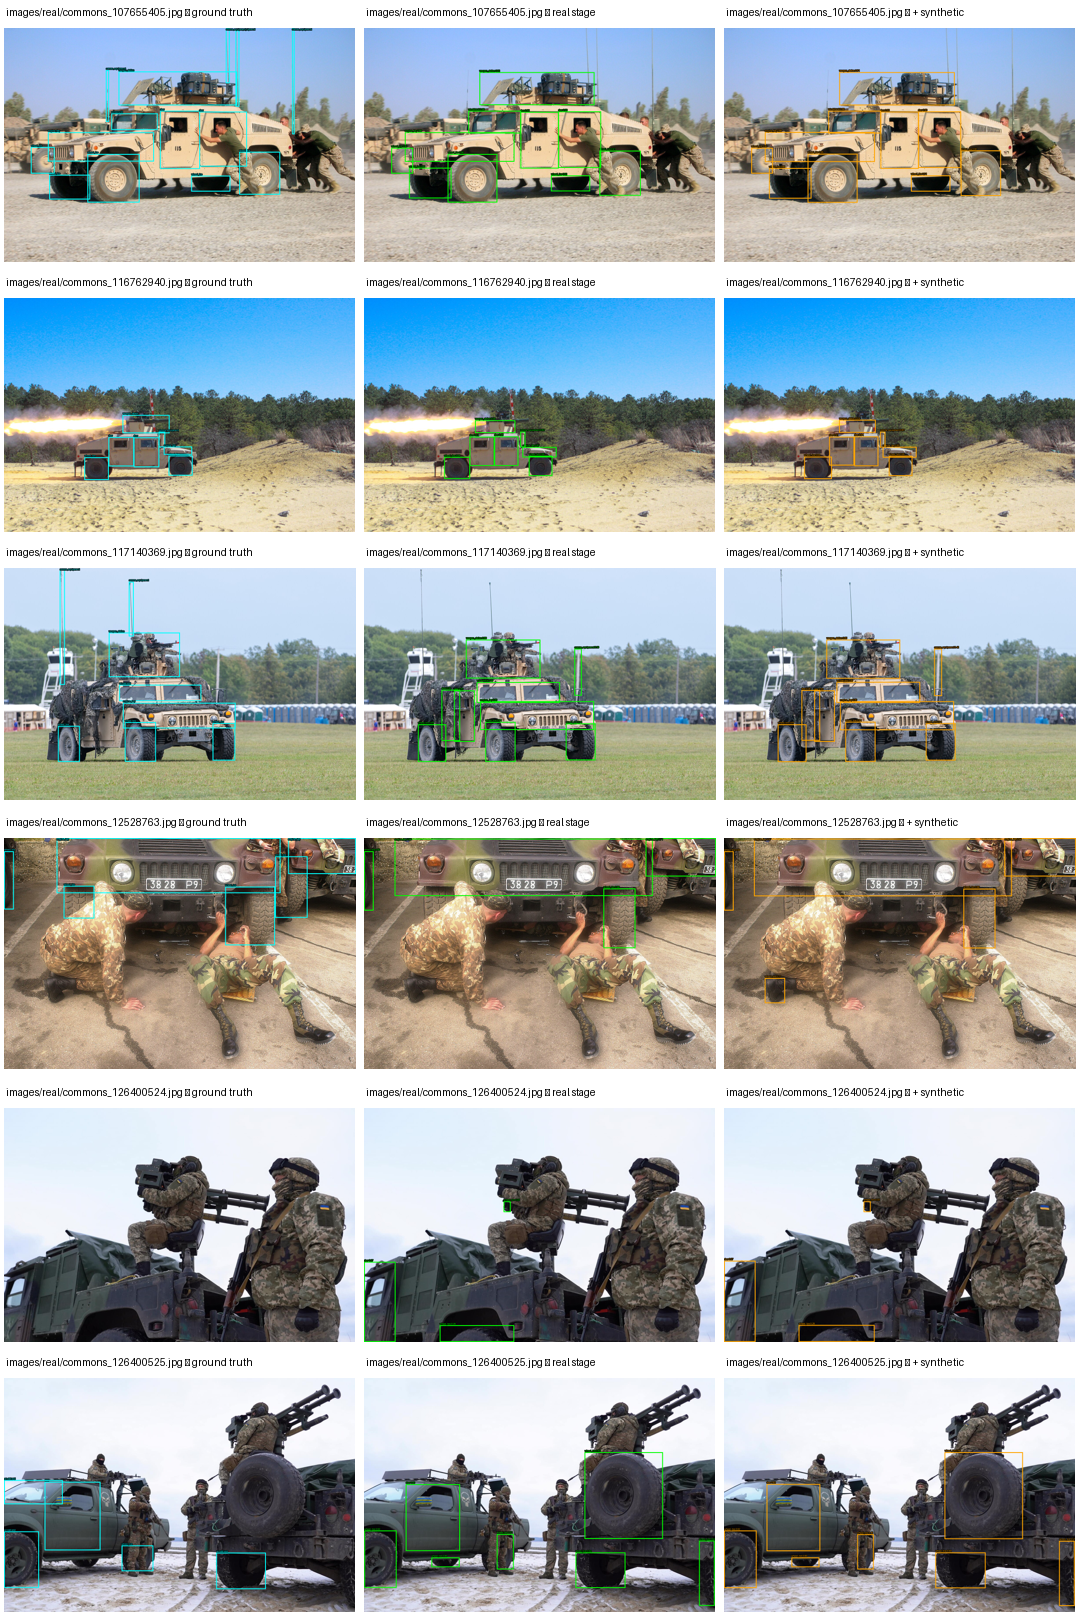

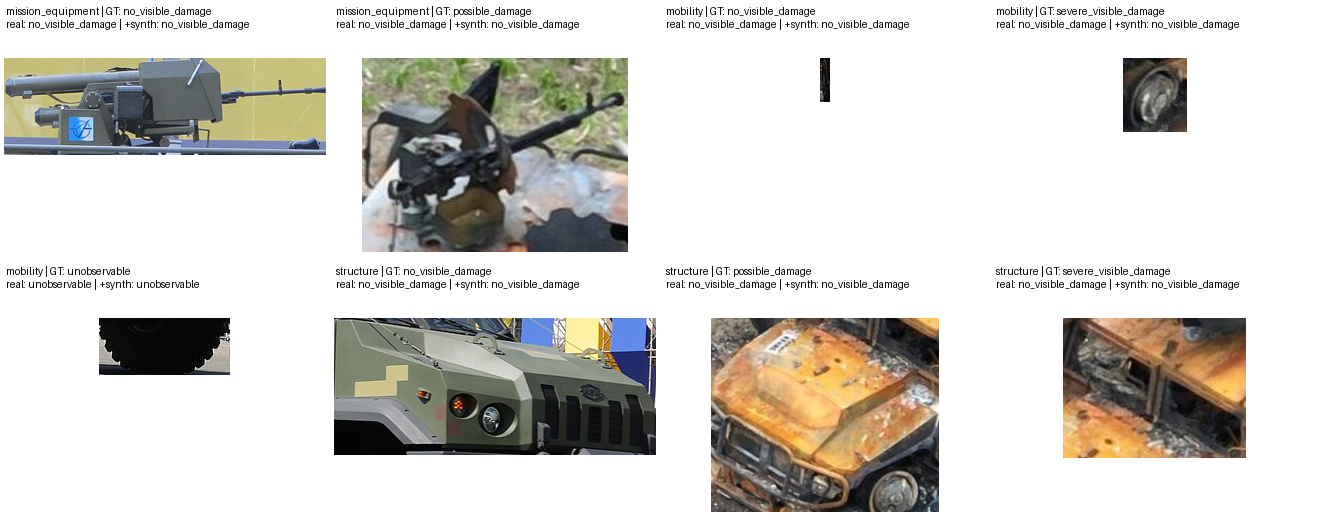

In [14]:
def fit_tile(image, size=(360, 270), header=28):
    image = image.copy()
    image.thumbnail((size[0] - 8, size[1] - header - 8))
    tile = Image.new("RGB", size, "white")
    tile.paste(image, ((size[0] - image.width) // 2, header))
    return tile

def draw_detector_boxes(image, boxes, class_names, color="lime"):
    rendered = image.copy()
    draw = ImageDraw.Draw(rendered)
    width = max(2, round(min(rendered.size) / 250))
    for box, score, class_id in boxes:
        x1, y1, x2, y2 = box
        x1, x2 = sorted((max(0, x1), min(rendered.width - 1, x2)))
        y1, y2 = sorted((max(0, y1), min(rendered.height - 1, y2)))
        label = class_names[int(class_id)] + (f" {score:.2f}" if score is not None else "")
        draw.rectangle((x1, y1, x2, y2), outline=color, width=width)
        draw.text((x1, max(0, y1 - 13)), label, fill=color,
                  stroke_width=2, stroke_fill="black")
    return rendered

def load_detector_for_inference(checkpoint_path):
    from yolox.exp import get_exp
    exp = get_exp(str(EXP_FILE), None)
    model = exp.get_model()
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    model.load_state_dict(checkpoint["model"])
    return exp, model.to(DEVICE).eval()

@torch.inference_mode()
def detector_predictions(exp, model, image_path, confidence=0.25):
    from yolox.data import ValTransform
    from yolox.utils import postprocess
    raw = cv2.imread(str(image_path))
    ratio = min(exp.test_size[0] / raw.shape[0], exp.test_size[1] / raw.shape[1])
    prepared, _ = ValTransform(legacy=False)(raw, None, exp.test_size)
    tensor = torch.from_numpy(prepared).unsqueeze(0).float().to(DEVICE)
    output = postprocess(model(tensor), exp.num_classes, confidence, exp.nmsthre)[0]
    if output is None:
        return []
    output = output.detach().cpu()
    boxes = (output[:, :4] / ratio).tolist()
    scores = (output[:, 4] * output[:, 5]).tolist()
    classes = output[:, 6].to(torch.int64).tolist()
    return [(box, score, class_id) for box, score, class_id in zip(boxes, scores, classes)]

def show_detector_inference_grid(max_images=6):
    payload = json.loads((DETECTOR_DATA_DIR / "annotations/real_test.json").read_text())
    class_names = [item["name"] for item in sorted(payload["categories"], key=lambda x: x["id"])]
    annotations = defaultdict(list)
    for row in payload["annotations"]:
        x, y, w, h = row["bbox"]
        annotations[int(row["image_id"])].append(
            ((x, y, x + w, y + h), None, int(row["category_id"]) - 1)
        )
    models = {stage: load_detector_for_inference(path)
              for stage, path in detector_checkpoints.items()}
    images = sorted(payload["images"], key=lambda row: row["file_name"])[:max_images]
    grid = Image.new("RGB", (3 * 360, len(images) * 270), "white")
    for row_index, record in enumerate(images):
        path = DETECTOR_DATA_DIR / record["file_name"]
        with Image.open(path) as source:
            raw = source.convert("RGB")
        panels = [
            ("ground truth", draw_detector_boxes(raw, annotations[int(record["id"])], class_names, "cyan")),
            ("real stage", draw_detector_boxes(
                raw, detector_predictions(*models["real"], path), class_names, "lime")),
            ("+ synthetic", draw_detector_boxes(
                raw, detector_predictions(*models["synthetic"], path), class_names, "orange")),
        ]
        for column, (label, panel) in enumerate(panels):
            tile = fit_tile(panel)
            ImageDraw.Draw(tile).text((6, 6), f"{record['file_name']} — {label}", fill="black")
            grid.paste(tile, (column * 360, row_index * 270))
    display(grid)

def show_damage_inference_grid(max_images=12, columns=4):
    by_model = {
        name: pd.read_csv(DAMAGE_TEST_DIR / f"{name}_predictions.csv").set_index("annotation_id")
        for name in damage_test_results
    }
    rows = crop_df[(crop_df.domain == "real") & (crop_df.split == "test")].copy()
    rows = rows.sort_values(["component_group", "damage_level", "annotation_id"])
    selected = rows.groupby(["component_group", "damage_level"], group_keys=False).head(1).head(max_images)
    tile_size = (330, 260)
    grid_rows = math.ceil(len(selected) / columns)
    grid = Image.new("RGB", (columns * tile_size[0], grid_rows * tile_size[1]), "white")
    for index, (_, row) in enumerate(selected.iterrows()):
        with Image.open(CROP_DIR / row.crop_file) as source:
            tile = fit_tile(source.convert("RGB"), tile_size, header=58)
        real = by_model[f"{row.component_group}_real"].loc[row.annotation_id]
        synthetic = by_model[f"{row.component_group}_synthetic"].loc[row.annotation_id]
        caption = (f"{row.component_group} | GT: {row.damage_level}\n"
                   f"real: {real.prediction} | +synth: {synthetic.prediction}")
        ImageDraw.Draw(tile).multiline_text((6, 5), caption, fill="black", spacing=3)
        grid.paste(tile, ((index % columns) * tile_size[0],
                          (index // columns) * tile_size[1]))
    display(grid)

if RUN_LONG_TRAINING:
    show_detector_inference_grid()
    show_damage_inference_grid()


## Takeaways


In [15]:
if RUN_LONG_TRAINING:
    detector_delta_val = (
        detector_metrics["synthetic"]["val"]["ap50_95"]
        - detector_metrics["real"]["val"]["ap50_95"]
    )
    detector_delta_test = (
        detector_metrics["synthetic"]["test"]["ap50_95"]
        - detector_metrics["real"]["test"]["ap50_95"]
    )
    damage_pivot = damage_test_table.pivot(index="group", columns="stage", values="macro_f1")
    damage_pivot["delta_synthetic_minus_real"] = (
        damage_pivot["synthetic"] - damage_pivot["real"]
    )
    display(damage_pivot)

    summary = {
        "run_name": RUN_NAME,
        "decision_basis": "fixed real validation metrics",
        "detector": {
            "validation_ap50_95_delta": detector_delta_val,
            "test_ap50_95_delta": detector_delta_test,
            "synthetic_stage_promoted": detector_delta_val > 0,
        },
        "damage_test_macro_f1_delta_by_group":
            damage_pivot["delta_synthetic_minus_real"].to_dict(),
        "synthetic_sources": list(SYNTHETIC_SOURCES),
        "caveat": "Synthetic data were not randomized as an intervention; deltas are paired model comparisons, not causal estimates.",
    }
    (RUN_DIR / "benchmark_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
    print(json.dumps(summary, indent=2))
else:
    print(
        "Preflight and dataset QA are complete. Set RUN_LONG_TRAINING=True, restart the "
        "kernel, and Run All. The final cell will write benchmark_summary.json."
    )


stage,real,synthetic,delta_synthetic_minus_real
group,,,
mission_equipment,0.247748,0.247748,0.000000
mobility,0.345238,0.345238,0.000000
structure,0.272662,0.289391,0.016729


{
  "run_name": "humvee_real_then_all_synthetic_20260917",
  "decision_basis": "fixed real validation metrics",
  "detector": {
    "validation_ap50_95_delta": -0.002912047830229525,
    "test_ap50_95_delta": 0.0016537782718503147,
    "synthetic_stage_promoted": false
  },
  "damage_test_macro_f1_delta_by_group": {
    "mission_equipment": 0.0,
    "mobility": 0.0,
    "structure": 0.016728679423576642
  },
  "synthetic_sources": [
    "synthetic_humvee_damage_v1",
    "synthetic_humvee_additions_v2"
  ],
  "caveat": "Synthetic data were not randomized as an intervention; deltas are paired model comparisons, not causal estimates."
}


The durable outputs live under `outputs/benchmarks/<RUN_NAME>/`: prepared
manifests, TensorBoard detector logs, stage checkpoints, paired metrics,
per-crop predictions, confusion matrices and `benchmark_summary.json`.

Known limitation: damage scores use human component boxes, so they isolate the
classifier. The detector benchmark measures localization/classification, while
a fully chained detector→crop→damage score remains a separate deployment test.
